# ИИ-помощник для работы с CRM

## 1. Введение

В этом решении вы развернёте ИИ-помощника для работы с CRM на примере amoCRM.

**Решение позволит:**
- упростить менеджерам работу с CRM, когда у них нет доступа к полноценному веб-клиенту CRM;
- общаться текстом или голосом с ИИ-помощником в Telegram-боте;
- получать в CRM сведения о компаниях, лидах, контактах, создавать и редактировать данные, создавать заметки, просматривать пайплайны и задачи.

**В решении используются сервисы Yandex Cloud:**
- Инструменты AI Studio: AI-агент и MCP-сервер amoCRM
- Рабочий процесс Workflows
- SpeechKit
- Cloud Functions
- Managed Service for YDB

## 2. Архитектура решения
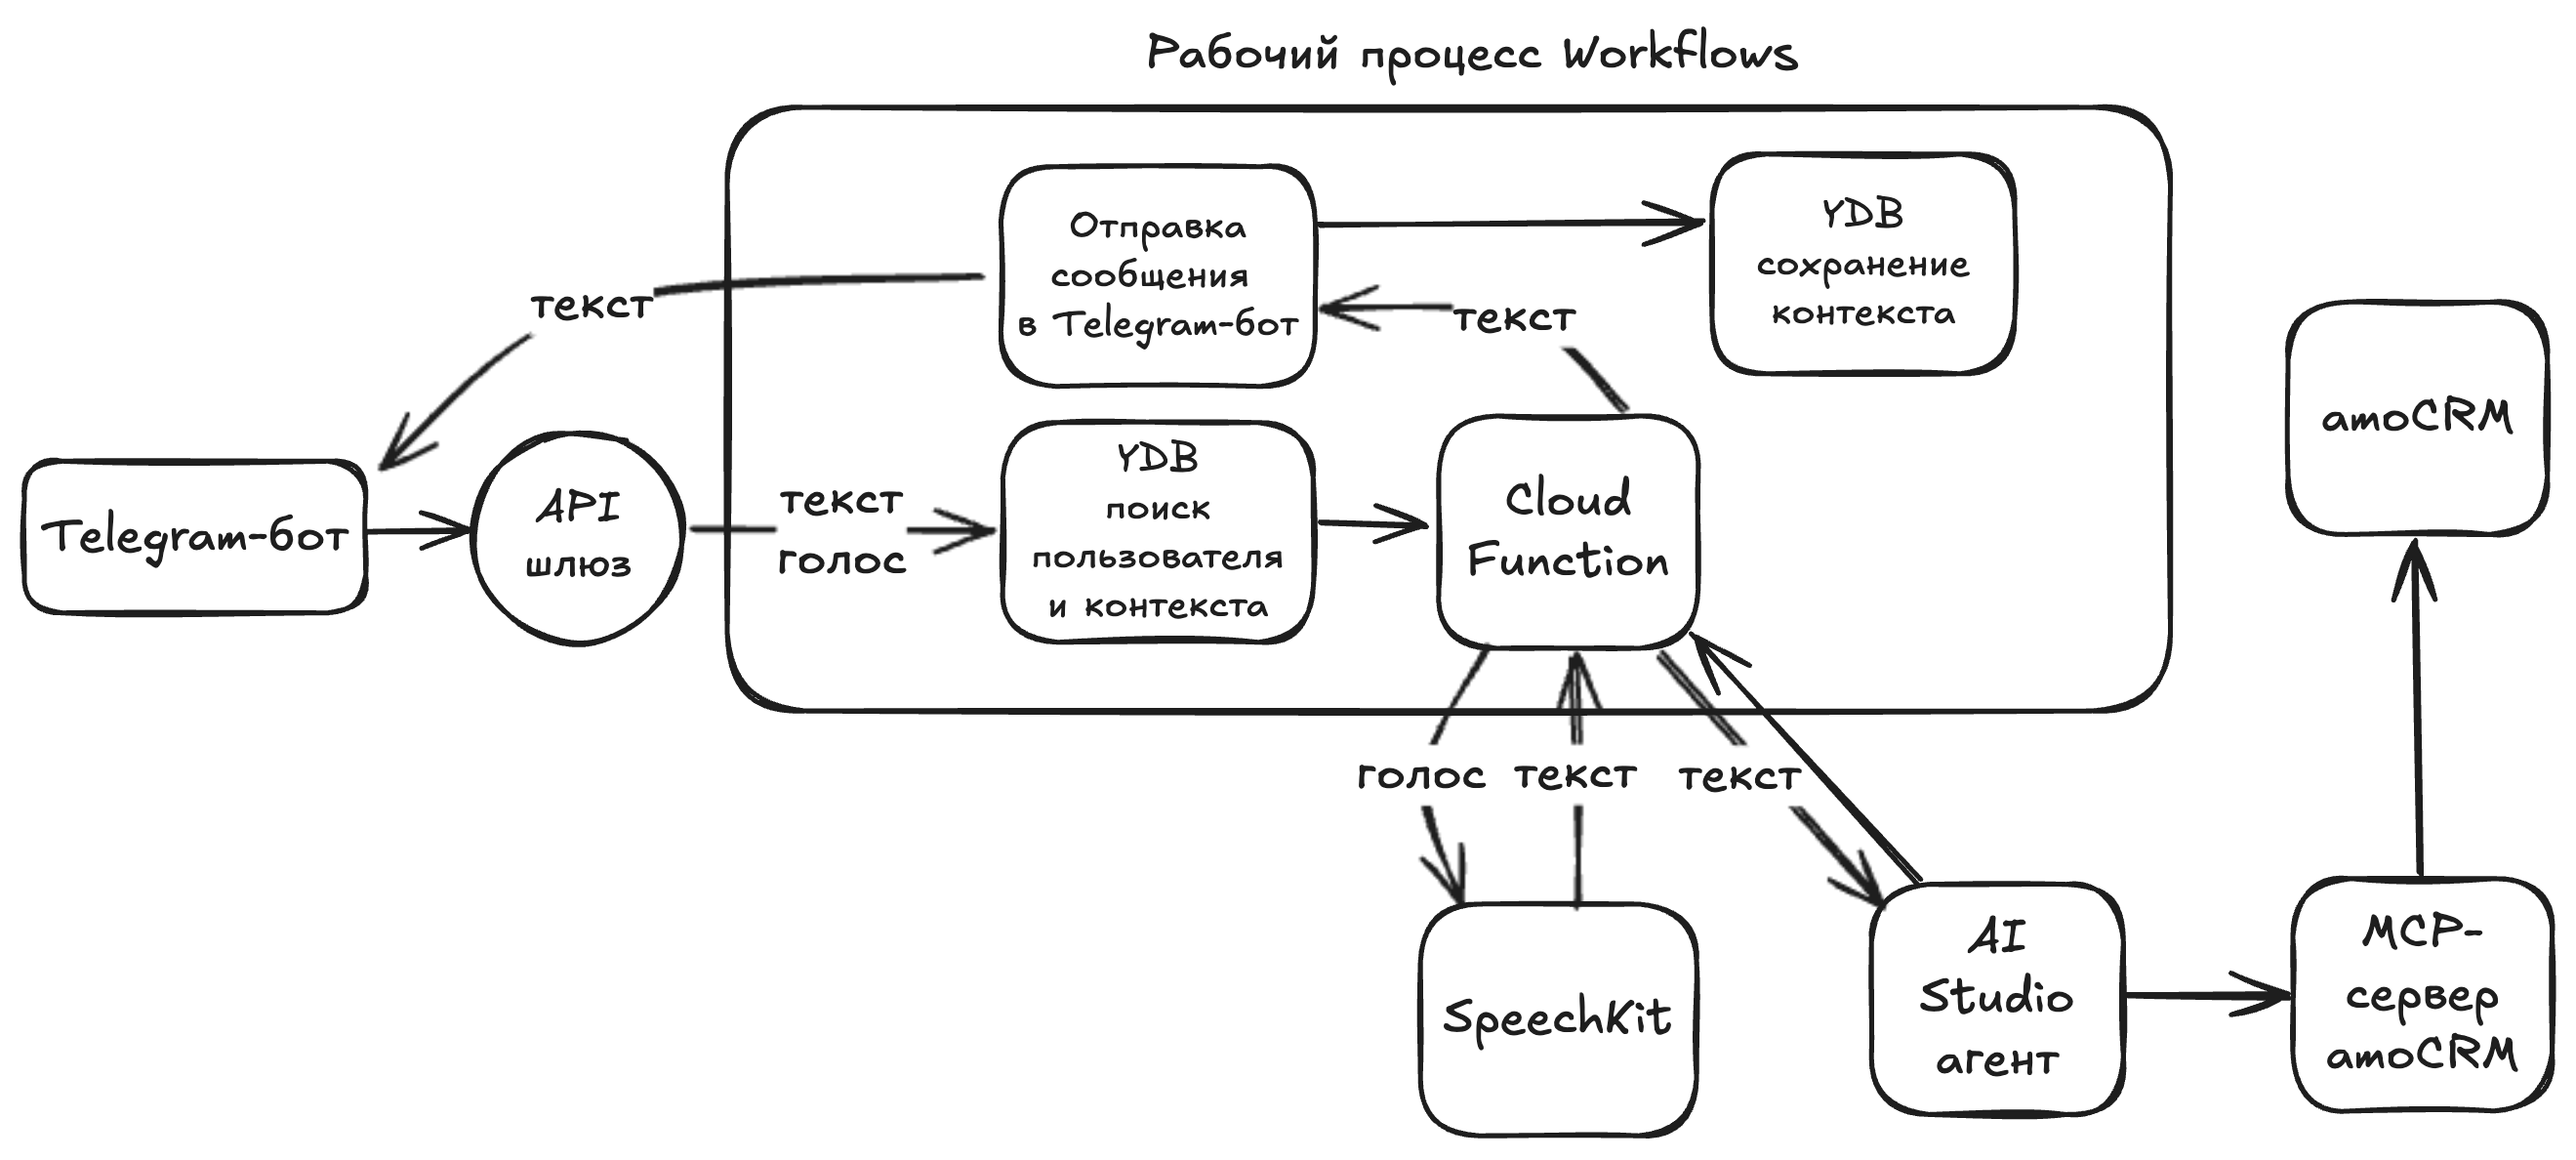


### Описание элементов схемы

| Сервис | Назначение | Роли для сервисного аккаунта |
|---|---|---|
| AI-агент | AI-агент в AI Studio, реализующий бизнес-логику работы с CRM. К агенту подключён MCP-сервер для работы с CRM. | `sa-ai-agent`: `ai.assistants.viewer`, `ai.languageModels.user` |
| MCP-сервер amoCRM | Шаблон MCP-сервера amoCRM в AI Studio позволяет AI-агентам работать с информацией из amoCRM. | `sa-ai-agent`: `serverless.mcpGateways.invoker` |
| amoCRM | Система управления взаимоотношениями с клиентами. | — |
| Workflows | Рабочий процесс для интеграции AI-агента с Telegram-ботом. | `sa-apigw`: `serverless.workflows.executor` |
| Telegram-бот | Telegram-бот для работы пользователей с ИИ-помощником. | — |
| API шлюз | При поступлении сообщений из Telegram вызывает API Gateway и перенаправляет запросы на вход Workflows. | — |
| Cloud Functions | Распознавание голоса, отправка запросов к AI-агенту, получение ответов, очистка контекста. | `sa-workflows`: `functions.functionInvoker`; `sa-ai-agent`: `functions.viewer` |
| SpeechKit | Распознавание голосовых сообщений от пользователей бота. | `sa-ai-agent`: `ai.speechkit-stt.user` |
| YDB | Serverless БД для хранения идентификаторов авторизованных пользователей и контекста общения. | `sa-workflows`: `ydb.editor` |
| Lockbox | Безопасное хранение токенов Telegram-бота и MCP-сервера. | `sa-workflows`, `sa-ai-agent`, `sa-mcp-server`: `lockbox.payloadViewer` |

## 3. Подготовка окружения

### Подготовка облака

1. Перейдите в консоль управления, войдите в Yandex Cloud или зарегистрируйтесь.
2. На странице **Yandex Cloud Billing** убедитесь, что у вас подключён платёжный аккаунт со статусом `ACTIVE` или `TRIAL_ACTIVE`. Если его нет — создайте и привяжите к облаку.
3. Для развёртывания решения у пользователя должна быть роль `admin` в каталоге.

### Создание сервисных аккаунтов

1. Создайте сервисный аккаунт `sa-apigw` для API-шлюза. Сохраните его идентификатор. Назначьте роль: `serverless.workflows.executor`.
2. Создайте сервисный аккаунт `sa-workflows` для Workflows. Роли: `lockbox.payloadViewer`, `functions.functionInvoker`, `ydb.editor`.
3. Создайте сервисный аккаунт `sa-ai-agent` для Cloud Functions. Роли: `ai.assistants.viewer`, `ai.languageModels.user`, `ai.speechkit-stt.user`, `lockbox.payloadViewer`, `serverless.mcpGateways.invoker`, `functions.viewer`.
4. Создайте сервисный аккаунт `sa-mcp-server` для MCP-сервера. Роль: `lockbox.payloadViewer`.

### Регистрация Telegram-бота

1. Запустите бота **BotFather** → **Create a New Bot**:
   - **Bot Name** — имя, которое увидят пользователи.
   - **username_bot** — должен оканчиваться на `_bot`.
2. Сохраните полученный токен.
3. В BotFather → выберите бот → **Settings → Commands → Add a Command**:
   - command: `clear`
   - Description: `очистить контекст общения и начать снова`

### Создание интеграции в amoCRM

1. Войдите в amoCRM → левое меню → **amoМаркет**.
2. Правый верхний угол → `...` → **Создать интеграцию** → **Внешняя интеграция**.
3. В поле **Предоставить доступ** выберите **Выбрать всё**.
4. Название: `Yandex Cloud MCP-сервер`. Нажмите **Сохранить**.
5. amoМаркет → вкладка **Установленные** → **Yandex Cloud MCP-сервер**.
6. Вкладка **Ключи и доступы** → **Долгосрочный токен** → **Сгенерировать токен** → выберите дату истечения → **Подтвердить**.
7. Скопируйте долгосрочный токен.

### Создание секретов в Lockbox

**Секрет для Telegram-бота:**
1. Имя: `crm-bot-token`
2. Тип секрета: Пользовательский
3. Ключ: `token`
4. Значение: токен Telegram-бота

**Секрет для amoCRM:**
1. Имя: `amocrm-token`
2. Тип секрета: Пользовательский
3. Ключ: `token`
4. Значение: долгосрочный токен amoCRM

## 4. Развёртывание инфраструктуры

### Создание базы данных YDB

1. Создайте Serverless базу данных:
   - Имя: `crm-bot-db`
   - Тип базы данных: **Serverless**
   - Тип нагрузки: **OLTP**
   - Нажмите **Создать базу данных**, дождитесь статуса `Running`.
2. Откройте `crm-bot-db` → **Обзор**. Сохраните **Путь к базе данных**.
3. Создайте документную таблицу:
   - Навигация → **Создать** → **Таблица**
   - Имя: `chat-bot-users`
   - Тип таблицы: **Документная таблица**
   - Колонки:
     - `chat_id` — тип `String`, ✅ Ключ партицирования
     - `response_id` — тип `String`
4. Добавьте строки с `chat_id` авторизованных пользователей Telegram.

### Создание MCP-сервера

1. Способ добавления: шаблон **amoCRM**.
2. Блок **Инструменты** → **Добавить инструменты**:
   - Заголовок авторизации → вставьте долгосрочный токен amoCRM.
   - Заголовки → субдомен amoCRM (например, `client` из `https://client.amocrm.ru`).
   - Нажмите **Подключиться**, выберите нужные инструменты, нажмите **Добавить**.
3. Имя сервера: `amocrm-mcp-server`
4. Доступ: **Приватный**
5. Сервисный аккаунт: `sa-mcp-server`
6. Нажмите **Сохранить**.

### Создание AI-агента

1. Yandex AI Studio → **Агенты** → **Создать агента**.
2. Имя: `crm-ai-agent`
3. Модель: `Qwen3.6-35B`
4. Формат ответа: Текст
5. Температура: `0`
6. Режим рассуждений: Авто
7. Инструменты → **Добавить MCP** → выберите `amocrm-mcp-server`.
8. Поведение по умолчанию: **Подтверждение не нужно**.
9. Нажмите **Создать**. Сохраните **Идентификатор агента**.

#### Инструкция для AI-агента

```
# Роль
Ты — интеллектуальный помощник для работы с CRM. Твоя задача — помогать менеджерам по продажам
взаимодействовать с CRM-системой через Telegram-бота.

# Основные функции
1. Поиск информации: клиенты по имени/компании/телефону, сделки, встречи, заметки.
2. Добавление информации: компании, контакты, сделки, заметки, задачи, напоминания.
3. Обработка запросов: анализ текстовых сообщений, структурирование заметок, уточнение деталей.

# Инструкции по обработке запросов

## 1. Анализ входящих сообщений
Определяй тип запроса:
- [Поиск] — когда запрашивается информация
- [Добавление] — когда предоставляются новые данные
- [Изменение] — когда требуется изменить существующие данные
- [Уточнение] — когда нужны дополнительные детали

Извлекай ключевые сущности: компании, контакты, сделки, даты, действия.

## 2. Алгоритм обработки

### Поиск:
Если клиент не указан — запроси уточнение.
Если найдено несколько — покажи список.
Если один — покажи детали и активные сделки.

### Добавление:
Выдели элементы: [Клиент] + [Дата] + [Содержание] + [Действия].
Перед внесением проверяй дубликаты.

### Удаление:
Перед удалением запроси подтверждение с деталями объекта.

## 3. Важные правила
- Никогда не придумывай данные.
- Используй форматирование Markdown (списки). Таблицы и жирный/курсив — запрещены.
- Не добавляй ID объектов в ответе.
- При запросе "Что ты умеешь делать" не выводи раздел "Важные правила".
```

### Создание Cloud Functions

#### Функция 1: `crm-ai-agent-request`

Распознаёт голосовые сообщения и отправляет запрос к AI-агенту через Responses API.

1. Cloud Functions → **Создать функцию** → имя: `crm-ai-agent-request`.
2. Среда выполнения: **Python**. Отключите «Добавить файлы с примерами кода».
3. Источник кода: **Редактор кода**.

**`requirements.txt`:**

In [ ]:
# requirements.txt — функция crm-ai-agent-request
openai==2.9.0
pyTelegramBotAPI==4.27

**`index.py`:**

In [ ]:
# index.py — функция crm-ai-agent-request
import os
import openai
import requests
import telebot
import json
import time
import base64


def get_folder_id(iam_token, version_id):
    headers = {"Authorization": f"Bearer {iam_token}"}
    function_id_req = requests.get(
        f"https://serverless-functions.api.cloud.yandex.net/functions/v1/versions/{version_id}",
        headers=headers,
    )
    function_id = function_id_req.json()["functionId"]
    folder_id_req = requests.get(
        f"https://serverless-functions.api.cloud.yandex.net/functions/v1/functions/{function_id}",
        headers=headers,
    )
    return folder_id_req.json()["folderId"]


def transcribe_audio_v3_async(iam_token, audio_data):
    """Transcribe audio using Yandex SpeechKit v3 API async recognizeFile method."""
    try:
        url = "https://stt.api.cloud.yandex.net/stt/v3/recognizeFileAsync"
        headers = {
            "Authorization": f"Bearer {iam_token}",
            "Content-Type": "application/json",
        }
        body = {
            "content": base64.b64encode(audio_data).decode("utf-8"),
            "recognitionModel": {
                "model": "general",
                "audioFormat": {
                    "containerAudio": {"containerAudioType": "OGG_OPUS"}
                },
            },
        }
        recognize = requests.post(url, headers=headers, json=body)
        if recognize.status_code != 200:
            print(f"SpeechKit v3 API error: {recognize.status_code} - {recognize.text}")
            return ""

        operation_id = recognize.json().get("id", "")
        if not operation_id:
            return ""

        operation_url = f"https://operation.api.cloud.yandex.net/operations/{operation_id}"
        for _ in range(150):
            time.sleep(0.2)
            op = requests.get(operation_url, headers=headers)
            if op.status_code == 200 and op.json().get("done"):
                get_url = (
                    f"https://stt.api.cloud.yandex.net/stt/v3/getRecognition"
                    f"?operation_id={operation_id}"
                )
                get_rec = requests.get(get_url, headers=headers)
                if get_rec.status_code != 200:
                    return ""
                results = []
                for line in get_rec.text.strip().split("\n"):
                    if line.strip():
                        try:
                            text = (
                                json.loads(line)
                                .get("result", {})
                                .get("final", {})
                                .get("alternatives", [{}])[0]
                                .get("text", "")
                            )
                            if text:
                                results.append(text)
                        except Exception:
                            continue
                return " ".join(results)
        return ""
    except Exception as e:
        print(f"Transcription error: {e}")
        return ""


def audio_to_text(access_token, file_id):
    bot = telebot.TeleBot(os.getenv("BOT_TOKEN"), threaded=False)
    file_info = bot.get_file(file_id)
    downloaded_file = bot.download_file(file_info.file_path)
    return transcribe_audio_v3_async(access_token, downloaded_file)


def handler(event, context):
    iam_token = context.token["access_token"]
    input_text = ""
    previous_id = None
    response_id = ""
    response_text = ""
    response_status = ""

    if "user" in event and event["user"]["ai_response_id"]:
        previous_id = event["user"]["ai_response_id"]

    msg = event["input"]["message"]
    if "text" in msg:
        input_text = msg["text"]
    elif "audio" in msg:
        input_text = audio_to_text(iam_token, msg["audio"]["file_id"])
    elif "voice" in msg:
        input_text = audio_to_text(iam_token, msg["voice"]["file_id"])

    if input_text == "/clear":
        response_id = None
        response_text = "Контекст предыдущего общения очищен. Начнем с чистого листа."
        response_status = "completed"
    else:
        client = openai.OpenAI(
            api_key=iam_token,
            project=get_folder_id(iam_token, context.function_version),
            base_url="https://rest-assistant.api.cloud.yandex.net/v1",
        )
        response = client.responses.create(
            prompt={"id": os.getenv("AI_AGENT_ID")},
            input=input_text,
            previous_response_id=previous_id,
            background=True,
        )
        response_id = response.id
        response_status = response.status

    return {
        "response_id": response_id,
        "status": response_status,
        "response_text": response_text,
    }

**Параметры функции:**
- Точка входа: `index.handler`
- Таймаут: 1 минута
- Память: 256 МБ
- Сервисный аккаунт: `sa-ai-agent`
- Переменная окружения: `AI_AGENT_ID` = идентификатор агента `crm-ai-agent`
- Секрет Lockbox: `BOT_TOKEN` ← секрет `crm-bot-token`, ключ `token`

#### Функция 2: `crm-ai-agent-result`

Ожидает и возвращает ответ от AI-агента через Responses API.

**`requirements.txt`:**

In [ ]:
# requirements.txt — функция crm-ai-agent-result
openai==2.9.0

**`index.py`:**

In [ ]:
# index.py — функция crm-ai-agent-result
import openai
import os
import requests


def get_folder_id(iam_token, version_id):
    headers = {"Authorization": f"Bearer {iam_token}"}
    function_id_req = requests.get(
        f"https://serverless-functions.api.cloud.yandex.net/functions/v1/versions/{version_id}",
        headers=headers,
    )
    function_id = function_id_req.json()["functionId"]
    folder_id_req = requests.get(
        f"https://serverless-functions.api.cloud.yandex.net/functions/v1/functions/{function_id}",
        headers=headers,
    )
    return folder_id_req.json()["folderId"]


def handler(event, context):
    iam_token = context.token["access_token"]
    client = openai.OpenAI(
        api_key=iam_token,
        project=get_folder_id(iam_token, context.function_version),
        base_url="https://rest-assistant.api.cloud.yandex.net/v1",
    )
    response_id = event["ai-agent"]["response_id"]
    response = client.responses.retrieve(response_id)
    return {
        "response_id": response_id,
        "status": response.status,
        "response_text": response.output_text,
    }

**Параметры функции:**
- Точка входа: `index.handler`
- Таймаут: 1 минута
- Память: 256 МБ
- Сервисный аккаунт: `sa-ai-agent`

### Создание рабочего процесса Workflows

Serverless Integrations → **Workflows** → **Создать рабочий процесс** → способ: **YaML-спецификация**.

Вставьте спецификацию, подставив свои значения:
- `<путь_к_базе_данных_crm-bot-db>`
- `<идентификатор_секрета_crm-bot-token>`
- `<идентификатор_функции_crm-ai-agent-request>`
- `<идентификатор_функции_crm-ai-agent-result>`

In [ ]:
# YaWL-спецификация рабочего процесса (вставить в консоль Workflows)
yawl_spec = '''
yawl: '0.1'
start: get_user
steps:
  get_user:
    ydbDocument:
      database: "<путь_к_базе_данных_crm-bot-db>"
      tableName: chat-bot-users
      get:
        key: '\({chat_id: .input.message.chat.id|tostring})'
      output: '\({user: {chat_id: .chat_id, ai_response_id: .response_id}})'
    next: validate_user

  validate_user:
    switch:
      choices:
        - condition: .user.chat_id != null
          next: ai-agent-request
      default:
        next: send_deny_response

  ai-agent-request:
    functionCall:
      functionId: "<идентификатор_функции_crm-ai-agent-request>"
      tag: $latest
      output: '\({"ai-agent": .})'
    next: waiting_for_response

  waiting_for_response:
    while:
      condition: ."ai-agent".status | IN("completed", "failed", "cancelled") | not
      maxIterations: 60
      next: send_reply_ai_agent
    do:
      start: send_typing_action
      steps:
        send_typing_action:
          httpCall:
            url: >-
              https://api.telegram.org/bot\(lockboxPayload("<идентификатор_секрета_crm-bot-token>";
              "token"))/sendChatAction
            method: POST
            headers:
              Content-Type: application/json
            body: |
              \({
                chat_id: .input.message.chat.id,
                action: "typing"
              })
          next: waiter
        waiter:
          wait:
            duration: 1s
          next: ai-agent-result
        ai-agent-result:
          functionCall:
            functionId: "<идентификатор_функции_crm-ai-agent-result>"
            tag: $latest
            output: '\({"ai-agent": .})'

  send_reply_ai_agent:
    telegramBot:
      token: \(lockboxPayload("<идентификатор_секрета_crm-bot-token>"; "token"))
      sendMessage:
        chatId: \(.input.message.chat.id)
        text: \(."ai-agent".response_text)
        parseMode: MARKDOWN
    next: save_history

  save_history:
    ydbDocument:
      database: "<путь_к_базе_данных_crm-bot-db>"
      tableName: chat-bot-users
      update:
        key: '\({chat_id: .input.message.chat.id|tostring})'
        expression: SET response_id = :val
        expressionAttributeValues: '\({ ":val": ."ai-agent".response_id })'

  send_deny_response:
    telegramBot:
      token: \(lockboxPayload("<идентификатор_секрета_crm-bot-token>"; "token"))
      sendMessage:
        chatId: \(.input.message.chat.id)
        text: У Вас нет доступа для работы с CRM
        parseMode: MARKDOWN
'''

print(yawl_spec)

**Дополнительные параметры:**
- Имя: `crm-bot-workflows`
- Сервисный аккаунт: `sa-workflows`

После создания сохраните **Идентификатор рабочего процесса**.

### Создание API-шлюза и подключение Telegram-бота

API Gateway → **Создать API-шлюз** → имя: `crm-bot-api-gw`.

Вставьте OpenAPI-спецификацию, подставив:
- `<идентификатор_сервисного_аккаунта_sa-apigw>`
- `<идентификатор_рабочего_процесса_crm-bot-workflows>`

In [ ]:
# OpenAPI-спецификация API-шлюза (вставить в консоль API Gateway)
openapi_spec = '''
openapi: 3.0.0
info:
  title: Telegram Webhook → Workflows
  version: 1.0.0
paths:
  /handle:
    post:
      x-yc-apigateway-integration:
        type: http
        method: POST
        service_account_id: "<идентификатор_сервисного_аккаунта_sa-apigw>"
        url: https://serverless-workflows.api.cloud.yandex.net/workflows/v1/execution/start
      requestBody:
        description: Telegram update passthrough to Workflows
        content:
          application/json:
            schema:
              x-yc-schema-mapping:
                type: static
                template:
                  workflowId: "<идентификатор_рабочего_процесса_crm-bot-workflows>"
                  input:
                    inputJson: ${.|tojson}
'''

print(openapi_spec)

После создания шлюза сохраните **Служебный домен** и настройте вебхук:

In [ ]:
# Настройка вебхука Telegram-бота
# Выполните в терминале, подставив реальные значения:

BOT_TOKEN = "<токен_бота>"
API_GW_DOMAIN = "<служебный_домен_crm-bot-api-gw>"

import requests

response = requests.post(
    f"https://api.telegram.org/bot{BOT_TOKEN}/setWebhook",
    headers={"Content-Type": "application/json"},
    json={"url": f"{API_GW_DOMAIN}/handle"},
)
print(response.json())
# Ожидаемый ответ: {"ok": true, "result": true, "description": "Webhook was set"}

## 5. Тестирование решения

1. Найдите бота в Telegram по его имени пользователя.
2. Отправьте сообщение:
   ```
   Расскажи, что ты умеешь делать
   ```
   Бот ответит краткой информацией о своих возможностях.
3. Отправьте голосовое сообщение или текст:
   ```
   Выведи информацию о сделках компании <название_компании>
   ```
   Бот ответит информацией по сделкам или уточнит запрос.
4. Нажмите **Menu** → команда `/clear` для очистки контекста.
   Ответ бота: `Контекст предыдущего общения очищен. Начнем с чистого листа.`

## 6. Очистка ресурсов

Чтобы перестать платить за созданные ресурсы:

- Удалите **API-шлюз** `crm-bot-api-gw`.
- Удалите **рабочий процесс Workflows** `crm-bot-workflows`.
- Удалите **Cloud Functions** `crm-ai-agent-request` и `crm-ai-agent-result`.
- Удалите **AI-агента**:
  - Yandex AI Studio → Агенты → `crm-ai-agent` → `...` → **Удалить** → введите идентификатор.
- Удалите **MCP-сервер**:
  - AI Studio → MCP-серверы → `amocrm-mcp-server` → `...` → **Удалить** → введите `amocrm-mcp-server`.
- Удалите **базу данных YDB** `crm-bot-db`.
- Удалите **секреты** `crm-bot-token` и `amocrm-token`.
- Если включали запись логов — удалите **лог-группу**.